In [1]:
import torch
import numpy as np
import tensorflow as tf
from transformers import RobertaTokenizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing import image as keras_image
import torch.nn.functional as F
import pandas as pd

# ===== PATHS =====
TEXT_MODEL_PATH = r"C:\Users\HP\Documents\Major_Final\Github-code\Module-2_Mini-2\Notebooks\roberta-base-fine-tuned.pth"
IMAGE_MODEL_PATH = r"C:\Users\HP\Documents\Major_Final\Github-code\Module-2_Mini-2\Notebooks\resnet50_disaster_finetuned.keras"

device = torch.device("cpu")

In [2]:
# ===== LOAD MODELS =====

# RoBERTa
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

text_model = torch.load(TEXT_MODEL_PATH, map_location=device)
if isinstance(text_model, dict):
    from transformers import RobertaForSequenceClassification
    text_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
    text_model.load_state_dict(torch.load(TEXT_MODEL_PATH, map_location=device))

text_model.to(device)
text_model.eval()

# ResNet
image_model = tf.keras.models.load_model(IMAGE_MODEL_PATH)


# ===== IMAGE PREDICT =====
def predict_image(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    preds = image_model.predict(x)
    return preds[0]   # probabilities


# ===== TEXT PREDICT =====
def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = text_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()[0]


# ===== DECISION FUSION =====
def decision_fusion(text_prob, image_prob, w_text=0.6, w_img=0.4):
    # ensure both are 2-class
    fused = (w_text * text_prob[:2]) + (w_img * image_prob[:2])
    return np.argmax(fused)




In [3]:
# ===== SAMPLE TEST DATA =====
# (replace with your dataset)
test_data = pd.read_csv("test.csv")

y_true = []
y_pred = []

# ===== RUN =====
for sample in test_data:
    text = sample["text"]
    img = sample["image"]
    label = sample["label"]

    text_prob = predict_text(text)
    image_prob = predict_image(img)

    pred = decision_fusion(text_prob, image_prob)

    y_true.append(label)
    y_pred.append(pred)



In [4]:
# ===== METRICS =====
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

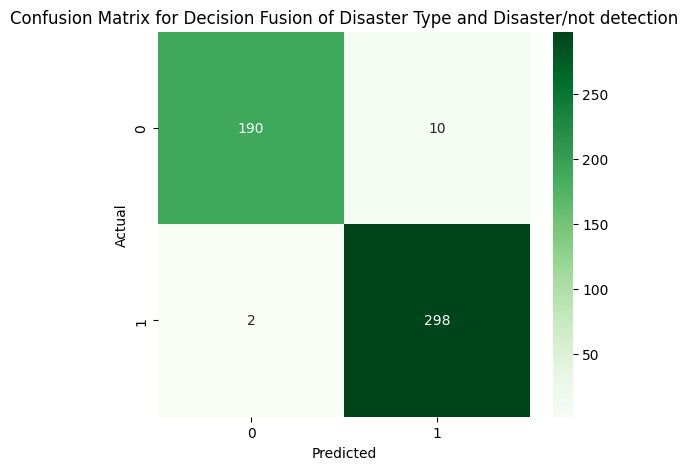

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Decision Fusion of Disaster Type and Disaster/not detection")

plt.show()

In [7]:
print("\nFusion Text + Image (Multimodal)")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Fusion Text + Image (Multimodal)
Accuracy  : 0.9100
Precision : 0.9080
Recall    : 0.9030
F1-score  : 0.9050
